In [50]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from curl_cffi import requests as cffi_requests

# 맥 애플고딕 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [4]:
import os

base_path = "/Users/kdt_0900_cjs/data_analysis/resource/dataset"
file_name = "titanic.csv"
file_path = os.path.join(base_path, file_name)

In [5]:
df = pd.read_csv(file_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [8]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
result = df.groupby("Pclass")["Survived"].agg(["count", "sum", "mean"])

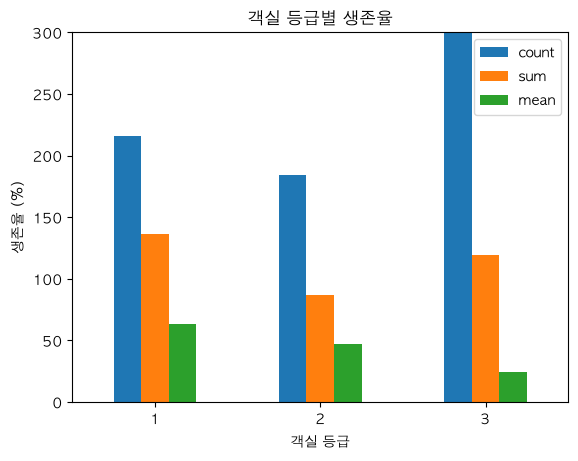

In [11]:
result["mean"] = result["mean"] * 100

result.plot(kind="bar")

plt.title("객실 등급별 생존율")
plt.xlabel("객실 등급")
plt.ylabel("생존율 (%)")
plt.ylim(0, 300)
plt.xticks(rotation=0)
plt.show()

In [12]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 윈도우 맑은 고딕 설정
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 맥 애플고딕 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [13]:
base_path = "/Users/kdt_0900_cjs/data_analysis/resource/dataset"
file_name = "hr_employee_attrition.csv"

file_path = os.path.join(base_path, file_name)

In [14]:
hr_df = pd.read_csv(file_path)
hr_df

,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
0,Yes,41,Female,Single,2,Sales,Sales Executive,Travel_Rarely,Yes,1,5993,11,0,8,6,2,4,1,3,0
1,No,49,Male,Married,1,Research & Development,Research Scientist,Travel_Frequently,No,8,5130,23,1,10,10,3,2,3,4,1
2,Yes,37,Male,Single,2,Research & Development,Laboratory Technician,Travel_Rarely,Yes,2,2090,15,0,7,0,4,3,3,3,0
3,No,33,Female,Married,4,Research & Development,Research Scientist,Travel_Frequently,Yes,3,2909,11,0,8,8,4,3,3,3,3
4,No,27,Male,Married,1,Research & Development,Laboratory Technician,Travel_Rarely,No,2,3468,12,1,6,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,36,Male,Married,2,Research & Development,Laboratory Technician,Travel_Frequently,No,23,2571,17,1,17,5,3,4,3,3,0
1466,No,39,Male,Married,1,Research & Development,Healthcare Representative,Travel_Rarely,No,6,9991,15,1,9,7,4,1,3,3,1
1467,No,27,Male,Married,3,Research & Development,Manufacturing Director,Travel_Rarely,Yes,4,6142,20,1,6,6,2,2,3,4,0
1468,No,49,Male,Married,3,Sales,Sales Executive,Travel_Frequently,No,2,5390,14,0,17,9,4,2,2,3,0


In [15]:
result = hr_df.groupby("OverTime")["Attrition"].apply(lambda x : (x == "Yes").mean() * 100)
result


OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64

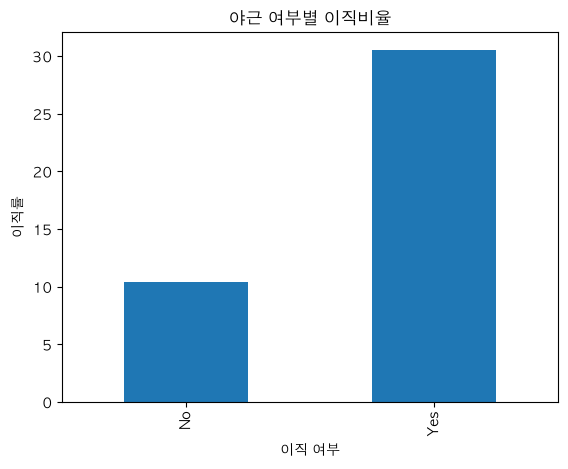

In [16]:
result.plot(kind = "bar")

plt.title("야근 여부별 이직비율")
plt.xlabel("이직 여부")
plt.ylabel("이직률")
plt.show()

In [27]:
result = hr_df.groupby("MonthlyIncome")["Attrition"].apply(lambda x : (x == "Yes").mean() * 100)
result = hr_df.groupby("Attrition")["MonthlyIncome"].agg(["count", "mean", "median"])
result


,count,mean,median
Attrition,,,
No,1233,6832.739659,5204.0
Yes,237,4787.092827,3202.0


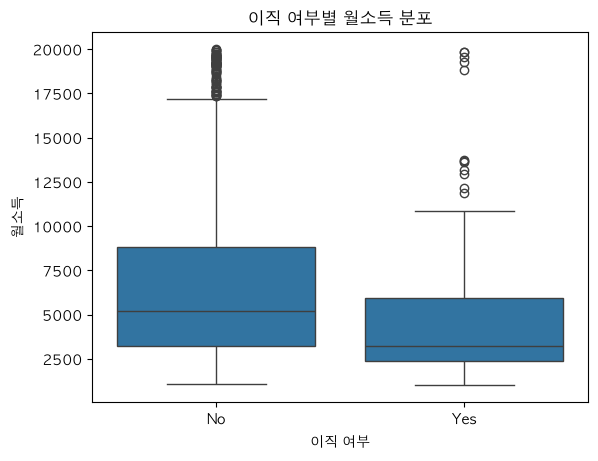

In [28]:
sns.boxplot(
    data=hr_df,
    x="Attrition",
    y="MonthlyIncome",
    order=["No", "Yes"]
)

plt.title("이직 여부별 월소득 분포")
plt.xlabel("이직 여부")
plt.ylabel("월소득")
plt.show()

In [31]:
result = hr_df.groupby("YearsSinceLastPromotion")["Attrition"].apply(lambda x : (x == "Yes").mean() * 100)
result

YearsSinceLastPromotion
0     18.932874
1     13.725490
2     16.981132
3     17.307692
4      8.196721
5      4.444444
6     18.750000
7     21.052632
8      0.000000
9     23.529412
10    16.666667
11     8.333333
12     0.000000
13    20.000000
14    11.111111
15    23.076923
Name: Attrition, dtype: float64

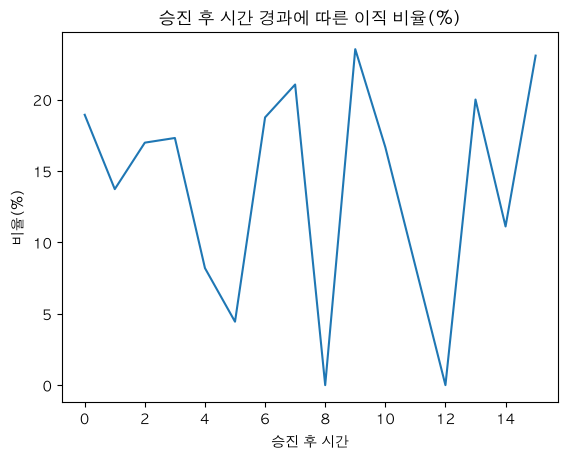

In [34]:
result.plot(kind = "line")
plt.title("승진 후 시간 경과에 따른 이직 비율(%)")
plt.ylabel("비율(%)")
plt.xticks(rotation =0)
plt.xlabel("승진 후 시간")
plt.show()

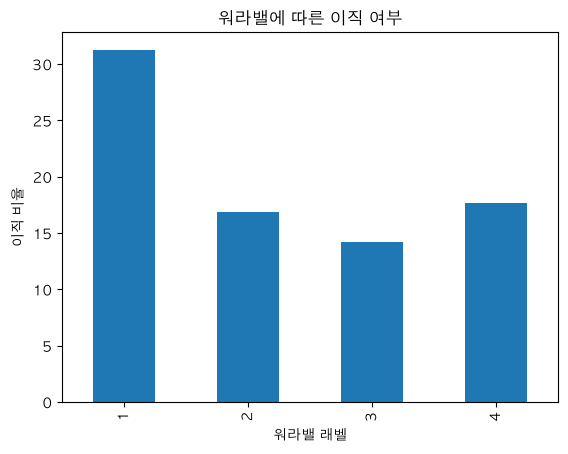

In [36]:
result = hr_df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x : (x == "Yes").mean() * 100)

result.plot(kind = "bar")
plt.title("워라밸에 따른 이직 여부")
plt.xlabel("워라밸 래벨")
plt.ylabel("이직 비율")
plt.show()

In [37]:
hr_df.describe()

,Age,Education,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,2.912925,9.192517,6502.931293,15.209524,0.793878,11.279592,7.008163,2.721769,2.728571,2.761224,3.153741,2.187755
std,9.135373,1.024165,8.106864,4707.956783,3.659938,0.852077,7.780782,6.126525,1.093082,1.102846,0.706476,0.360824,3.222430
min,18.000000,1.000000,1.000000,1009.000000,11.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,0.000000
25%,30.000000,2.000000,2.000000,2911.000000,12.000000,0.000000,6.000000,3.000000,2.000000,2.000000,2.000000,3.000000,0.000000
50%,36.000000,3.000000,7.000000,4919.000000,14.000000,1.000000,10.000000,5.000000,3.000000,3.000000,3.000000,3.000000,1.000000
75%,43.000000,4.000000,14.000000,8379.000000,18.000000,1.000000,15.000000,9.000000,4.000000,4.000000,3.000000,3.000000,3.000000
max,60.000000,5.000000,29.000000,19999.000000,25.000000,3.000000,40.000000,40.000000,4.000000,4.000000,4.000000,4.000000,15.000000


In [48]:
hr_df[["BusinessTravel", "Attrition"]].isna().sum()
hr_df.groupby("BusinessTravel").size()

BusinessTravel
Non-Travel            150
Travel_Frequently     277
Travel_Rarely        1043
dtype: int64

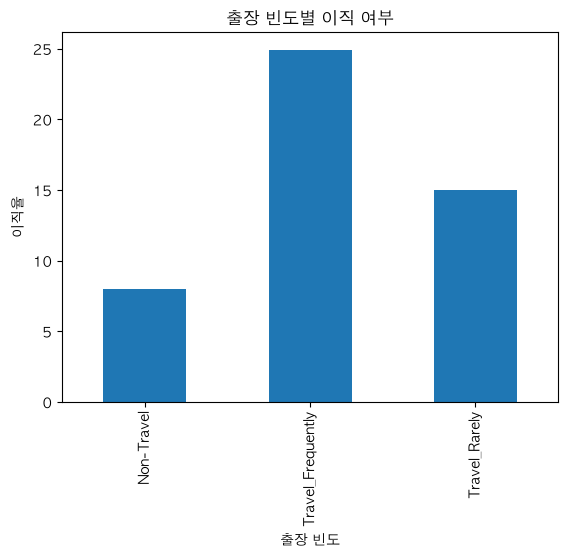

In [44]:
result = hr_df.groupby("BusinessTravel")["Attrition"].apply(lambda x : (x == "Yes").mean() * 100)

result.plot(kind = "bar")
plt.title("출장 빈도별 이직 여부")
plt.xlabel("출장 빈도")
plt.ylabel("이직율")
plt.show()

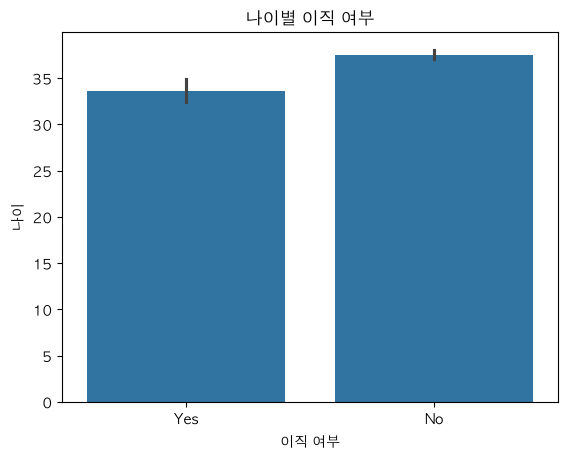

In [57]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from curl_cffi import requests as cffi_requests

sns.barplot(hr_df, x="Attrition", y="Age")

plt.title("나이별 이직 여부")
plt.xlabel("이직 여부")
plt.ylabel("나이")
plt.show()

In [64]:
promo_df = hr_df.groupby("YearsSinceLastPromotion")["Attrition"].agg(
    YesRate=lambda x: (x == "Yes").mean() * 100,
    NoRate=lambda x: (x == "No").mean() * 100,
).reset_index()

In [65]:
promo_df

,YearsSinceLastPromotion,YesRate,NoRate
0,0,18.932874,81.067126
1,1,13.725490,86.274510
2,2,16.981132,83.018868
3,3,17.307692,82.692308
4,4,8.196721,91.803279
5,5,4.444444,95.555556
6,6,18.750000,81.250000
7,7,21.052632,78.947368
8,8,0.000000,100.000000
9,9,23.529412,76.470588


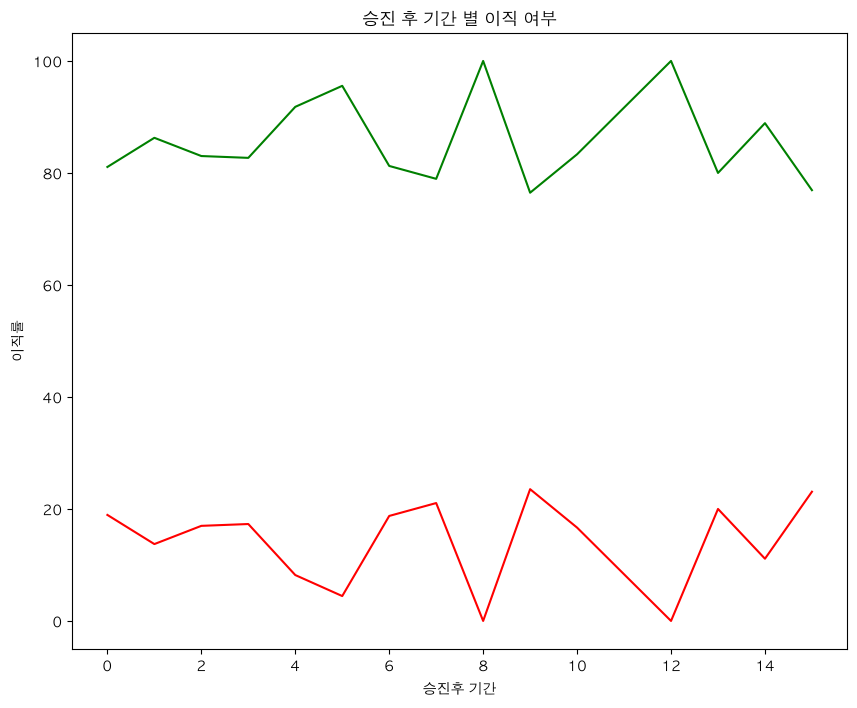

In [67]:
plt.figure(figsize = (10, 8))

# plt.plot(promo_df["YearsSinceLastPromotion"], promo_df["YesRate"], color="red", label ="이직")
# plt.plot(promo_df["YearsSinceLastPromotion"], promo_df["NoRate"], color="green", label ="이직(No)")

sns.plot(data=promo_df, x = "Ye)

plt.title("승진 후 기간 별 이직 여부")
plt.xlabel("승진후 기간")
plt.ylabel("이직률")
plt.show()

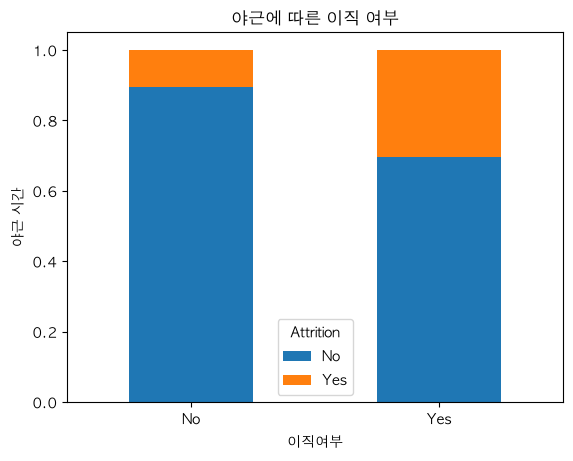

In [79]:
result = (pd.crosstab(hr_df["OverTime"], hr_df["Attrition"], normalize="index"))

result.plot(kind = "bar", stacked = True)  
plt.title("야근에 따른 이직 여부")
plt.xlabel("이직여부")
plt.xticks(rotation =0)
plt.ylabel("야근 시간")
plt.show()

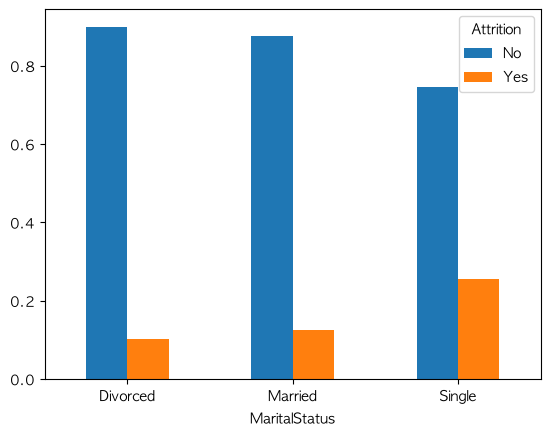

In [83]:
marrage_result1= (pd.crosstab(hr_df["MaritalStatus"], hr_df["Attrition"], normalize="index"))

marrage_result1.plot(kind="bar")
plt.xticks(rotation =0)
plt.show()

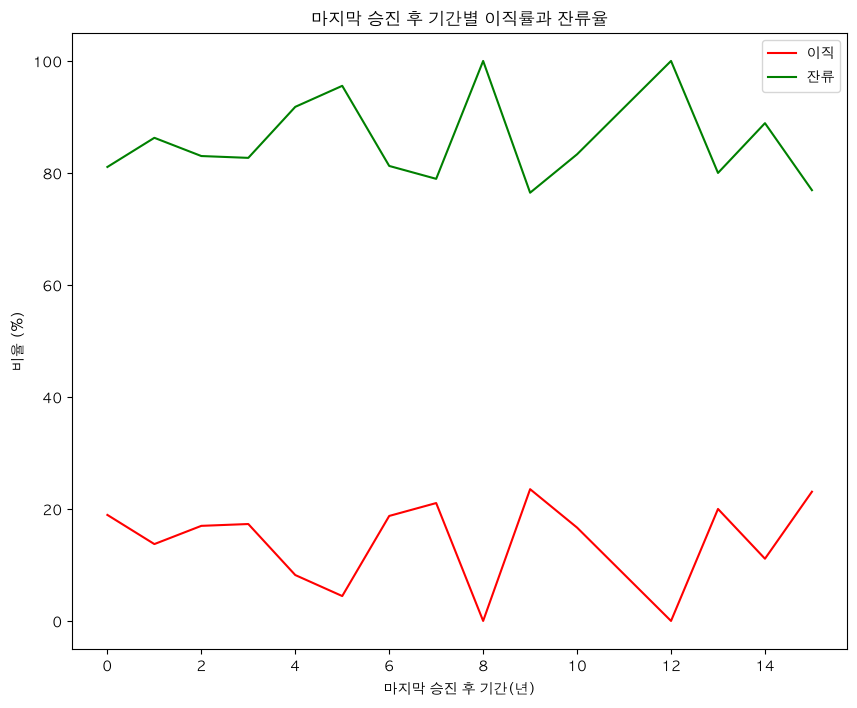

In [84]:
plt.figure(figsize=(10, 8))

sns.lineplot(
    data=promo_df,
    x="YearsSinceLastPromotion",
    y="YesRate",
    color="red",
    label="이직"
)

sns.lineplot(
    data=promo_df,
    x="YearsSinceLastPromotion",
    y="NoRate",
    color="green",
    label="잔류"
)

plt.title("마지막 승진 후 기간별 이직률과 잔류율")
plt.xlabel("마지막 승진 후 기간(년)")
plt.ylabel("비율 (%)")
plt.legend()
plt.show()

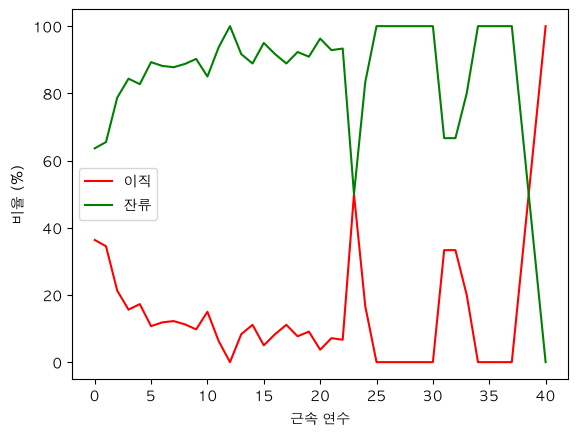

In [98]:
result = (pd.crosstab(hr_df["YearsAtCompany"], hr_df["Attrition"], normalize="index") * 100).reset_index()
sns.lineplot(data = result, x="YearsAtCompany", y = "Yes", color="red", label="이직")
sns.lineplot(data = result, x="YearsAtCompany", y = "No", color="green", label="잔류")

plt.ylabel("비율 (%)")
plt.xlabel("근속 연수")
plt.legend()
plt.show()

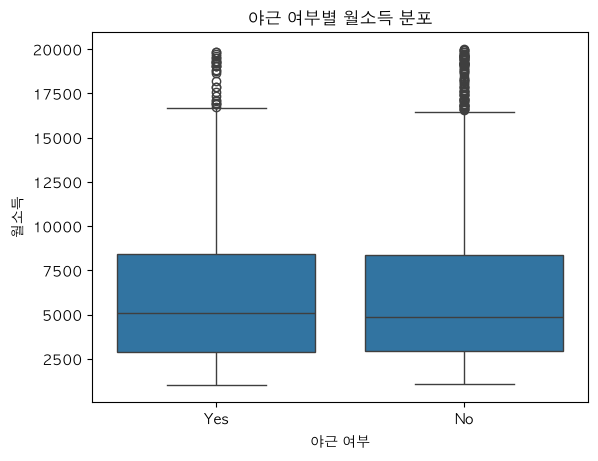

In [104]:
result = hr_df.groupby("OverTime")["MonthlyIncome"].agg(["mean", "median"])
sns.boxplot(data=hr_df, x="OverTime", y="MonthlyIncome")

plt.title("야근 여부별 월소득 분포")
plt.xlabel("야근 여부")
plt.ylabel("월소득")
plt.show()

In [106]:
print(hr_df["Department"].isna().sum())
print(hr_df["MonthlyIncome"].isna().sum())

0
0


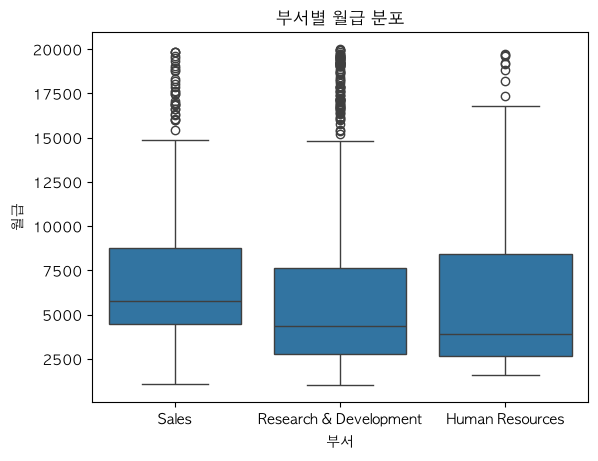

In [110]:
result = hr_df.groupby("Department")["MonthlyIncome"].agg(["mean"])

sns.boxplot(data = hr_df, x = "Department", y = "MonthlyIncome")

plt.title("부서별 월급 분포")
plt.xlabel("부서")
plt.ylabel("월급")
plt.show()